## CMPE-257, Machine Learning, Summer 2026
## Week 1: Introduction to Machine Learning
In this workbook, you will be exploring the perceptron learning algorithm:
- the perceptron as a binary classifier
- convergence and the learning rate parameter
- term project ideas...

In [56]:
# YOUR NAME: <Meenakshi Rajpurohit>

In [57]:
# Loading required modules
import random as rd
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

## PART 1: The Perceptron as a Binary Classifier

In [58]:
# The following three functions provide the basis for the exporatory work you will be
# conducting in this coding session, study them and make sure you understand what they do

# PLA_MSE: computes the mean square error over a given set of data samples
# - dtn: set of data samples (list of numpy arrays)
# - tgt: set of traget values (list)
# - model: the perceptron weights (numpy array)

def pla_mse(dtn,tgt,model):
    tst = []
    for xt in dtn:
        tst.append(np.sign(sum(xt*model)))
    return sum([(x-y)**2 for x,y in zip(tst,tgt)])/len(tgt)

# PLA_TRAIN: implements the perceptron learning algorithm
# - dtx: set of data samples (list of lists)
# - tgt: set of traget values (list)
# - wgt: initial set of weights (list of len=3) or weights are ramdomly generated
# - seq: data sequence (list of len>0) or sequence is randomly generated
# - nsteps: the maximum number of iterations (int)
# - thld: error threshold for algorithm termination
# note: this script assumes a linear classifier in 2D space (three weights only)

def pla_train(dtx,tgt,wgt,seq,nsteps=1000,thld=0.001):

    # initialization step
    data = [np.array(xn) for xn in [[1]+xy for xy in dtx]]
    target = tgt.copy()
    if len(wgt)==3: wt = [np.array(wgt)]
    else: wt = [np.array([rd.uniform(-3.0,3.0) for x in range(3)])]
    if len(seq)>0: nvals = seq.copy()
    else: nvals = [rd.randint(0,len(data)-1) for x in range(nsteps)]
    mse = [pla_mse(data,target,wt[-1])]

    # perceptron learning algorithm
    for k,n in enumerate(nvals):
        if mse[-1]<thld: break
        xt = data[n]
        yt = np.sign(sum(xt*wt[-1]))
        error = yt - target[n]
        if error == 0.0: continue
        new = wt[-1] - error*xt
        wt.append(new)
        mse.append(pla_mse(data,target,wt[-1]))
        if mse[-1]<thld: break

    # stores the training history into a data frame
    platrn = pd.DataFrame(np.array(wt),columns=['W0','W1','W2'])
    platrn['slope'] = -platrn['W1'].values/platrn['W2'].values
    platrn['intercept'] = -platrn['W0'].values/platrn['W2'].values
    platrn['mse'] = mse
    return platrn

# PLA_PLOT: creates plots for a given training-history data frame
# - dtx: set of data samples (list of lists)
# - tgt: set of traget values (list)
# - pla_df: the training-history data frame (output from PLA_TRAIN)
# note: this script also assumes a linear classifier in 2D space (three weights only)

def pla_plots(dtx,tgt,pla_df):

    fig, ax = plt.subplots(2,2,figsize=(10,8))

    # first plot: evelution of perceptron weights through the training steps
    wcols = [x for x in pla_df.columns.values if 'W' in x]
    for col in wcols:
        ax[0,0].plot(pla_df[col].values,'*:',label=col)
    ax[0,0].legend()
    ax[0,0].set_title('Perceptron Weights')

    # second plot: evolution of the mean square error through the training steps
    ax[0,1].plot(pla_df['mse'].values,'*:',label='mse')
    ax[0,1].legend()
    ax[0,1].set_title('Mean Square Error')

    # third and fourth plot: initial and final classification boundaries with data points
    mark = ['*b' if x==1.0 else '*r' for x in tgt]
    for k in range(2):
        for n,xy in enumerate(dtx):
            ax[1,k].plot(xy[0],xy[1],mark[n])
    titles = ['Initial Model','Final Model']
    xvals = [x[0] for x in dtx]
    xx = np.arange(min(xvals)-1.0,max(xvals)+2.0)
    for n,k in enumerate([0,pla_df.shape[0]-1]):
        m = pla_df['slope'].values[k]
        b = pla_df['intercept'].values[k]
        tag = 'y = '+'{:6.3f}'.format(m)+' x + '+'{:6.3f}'.format(b)
        ax[1,n].plot(xx,[m*s+b for s in xx],'-',label=tag)
        ax[1,n].legend()
        ttl = titles[n]+' (MSE='+'{:6.3f}'.format(pla_df['mse'].values[k])+')'
        ax[1,n].set_title(ttl)


,W0,W1,W2,slope,intercept,mse
0,-3.0,0.0,2.0,-0.0,1.500000,1.0
1,-5.0,-8.0,-2.0,-4.0,-2.500000,2.0
2,-3.0,-6.0,4.0,1.5,0.750000,1.0
3,-1.0,0.0,12.0,-0.0,0.083333,2.0
4,-3.0,-8.0,8.0,1.0,0.375000,0.0


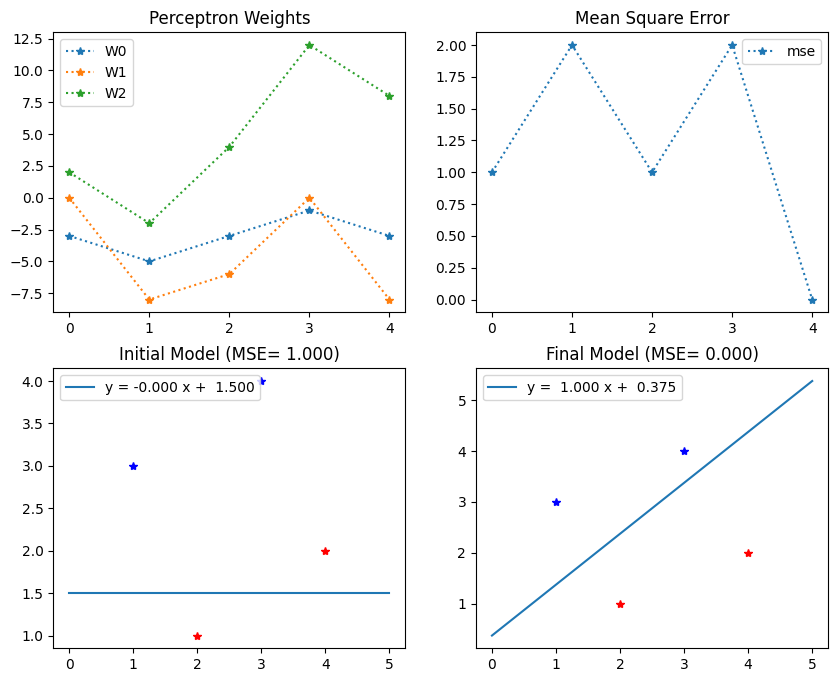

In [59]:
# Exercise #1: reproduce the example from class, display the results and generate the plots

# data samples and target values
dataset = [[1,3],[2,1],[3,4],[4,2]]
targets = [1.0,-1.0,1.0,-1.0]

# initial set of weights
weights = [-3.0,0.0,2.0]

# sample sequence to run the algorithm
sampleseq = [0,3,0,2,2,3]

training_table = pla_train(dataset,targets,weights,sampleseq)
display(training_table)

pla_plots(dataset,targets,training_table)

In [60]:
# How results in exercises #1 compare to the example you work on in class?
# <They matches exactly, a small difference is that class table lists all 6 iterations, including the step where error =0 and there is no update>

,W0,W1,W2,slope,intercept,mse
0,5.0,-1.0,-1.0,-1.000000,5.000000,2.00
1,3.0,-5.0,-3.0,-1.666667,1.000000,2.00
2,5.0,1.0,5.0,-0.200000,-1.000000,2.00
3,3.0,-3.0,3.0,1.000000,-1.000000,0.25
4,2.0,-5.0,2.0,2.500000,-1.000000,1.00
5,4.0,1.0,10.0,-0.100000,-0.400000,2.00
6,2.0,-7.0,6.0,1.166667,-0.333333,0.00


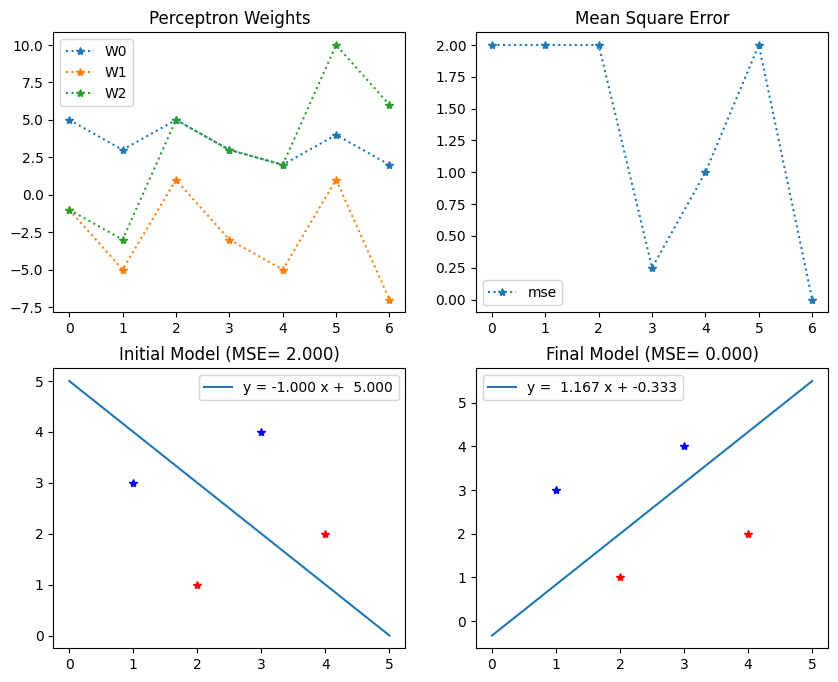

In [61]:
# Exercise #2: consider the new proposed set of weights and use a random sample sequence,
# display the results and generate the plots

# data samples and target values
dataset = [[1,3],[2,1],[3,4],[4,2]]
targets = [1.0,-1.0,1.0,-1.0]

# the new initial set of weights
weights = [5.0,-1.0,-1.0]

# forces for a random sequnece of samples
sampleseq = []

# add your code here...
training_table = pla_train(dataset,targets,weights,sampleseq)
display(training_table)

pla_plots(dataset,targets,training_table)


In [62]:
# What are you main observations from exercise #2?
# <1. Even with diffrenet initial = [5.0,-1.0,-1.0] and random sample sequence, the perceptron still converges to MSE=0, beacause the data is lineraly separable 2. It converges to different solution than exercise 1, final weights [0, -7, 6] and the slopw is 1.167 it shows that the separating line is not unique. 3. This run took 7 updates and in the exercise 1 was 4 update, count varies rach time I run because the sample sequence is random. 4. MSE is still non monotonic it drops to 0.25 and rises back to 2.0 in the last reaches zero. it shows that each update only corrects the single point it look at. >

,W0,W1,W2,slope,intercept,mse
0,-0.5,-0.7,1.0,0.7,0.5,0.0


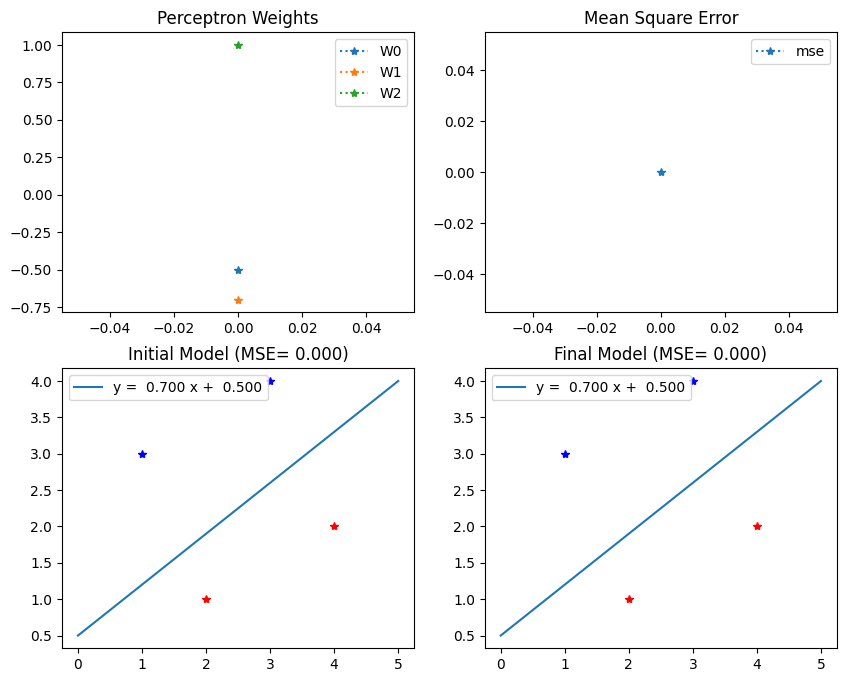

In [63]:
# Exercise #3: consider a new initial set of weights, display the results and generate the plots
# data samples and target values
dataset = [[1,3],[2,1],[3,4],[4,2]]
targets = [1.0,-1.0,1.0,-1.0]
# the new initial set of weights
weights = [-0.5,-0.7,1.0]

# forces for a random sequnece of samples
sampleseq = []

# add your code here...
training_table = pla_train(dataset,targets,weights,sampleseq)
display(training_table)

pla_plots(dataset,targets,training_table)


In [64]:
# What is special about the inital set of weigths considered in exercise #3?
# <The initial line y = 0.7x + 0.5 separates all four points correctly so the algorithm performs zero updates and stops immediately.>

,W0,W1,W2,slope,intercept,mse
0,0.5,0.7,-1.0,0.700000,0.500000,4.0
1,-1.5,-3.3,-3.0,-1.100000,-0.500000,2.0
2,0.5,-1.3,3.0,0.433333,-0.166667,2.0
3,-1.5,-5.3,1.0,5.300000,1.500000,2.0
4,0.5,0.7,9.0,-0.077778,-0.055556,2.0
5,-1.5,-7.3,5.0,1.460000,0.300000,1.0
6,0.5,-1.3,13.0,0.100000,-0.038462,2.0
7,-1.5,-5.3,11.0,0.481818,0.136364,0.0


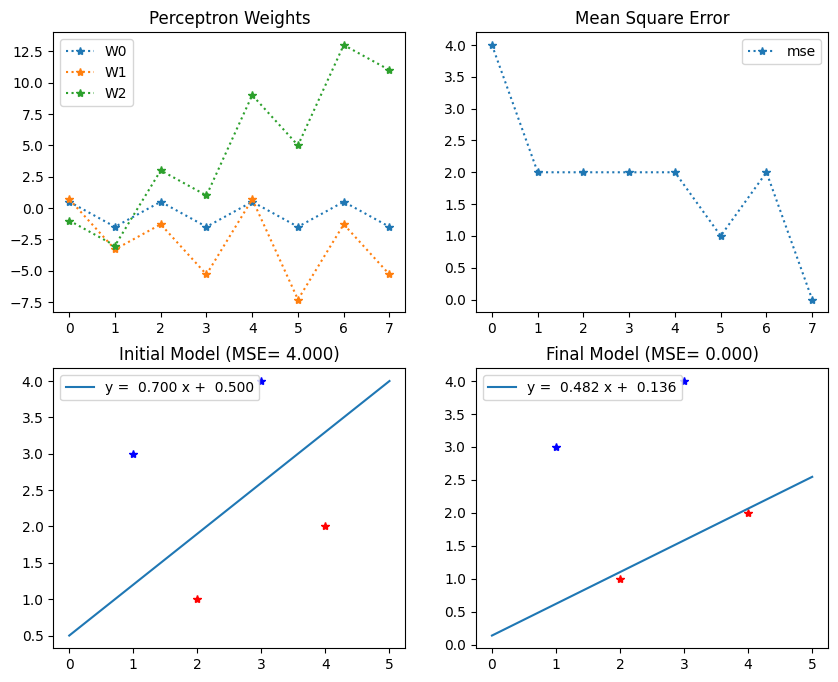

In [65]:
# Exercise #4: consider another initial set of weights, display the results and generate the plots

# data samples and target values
dataset = [[1,3],[2,1],[3,4],[4,2]]
targets = [1.0,-1.0,1.0,-1.0]

# the new initial set of weights
weights = [0.5,0.7,-1.0]

# forces for a random sequnece of samples
sampleseq = []

# add your code here...
training_table = pla_train(dataset,targets,weights,sampleseq)
display(training_table)

pla_plots(dataset,targets,training_table)


In [66]:
# Compare the initial models in #3 and #4? What do you observe? Can you explain the results in #4?
# < #4th weights are the negatives of #3's. since the slope and intercept depends only on the ratio -w1/w2 and -w0/w2, both have same intial line eq. 2. Negating the weights flips sign(W. x), so #4 classifies every point the opposite way. that is why #4 starts wil maximally wrong(MSE = 4.0, All points misclassified) >

## Part 2: Convergence and the Learning Rate Parameter

In [67]:
# Exercise #5: for the given initial conditions, repeat the training 20 times and print
# the total number of iterations for each training run (i.e. training_table.shape[0])

# data samples and target values
dataset = [[1,3],[2,1],[3,4],[4,2]]
targets = [1.0,-1.0,1.0,-1.0]

# initial set of weights
weights = [-3.0,0.0,2.0]

# forces for a random sequnece of samples
sampleseq = []

# add your code here...
for i in range(20):
    training_table = pla_train(dataset,targets,weights,sampleseq)
    print(training_table.shape[0])


10
10
10
5
10
5
10
5
10
5
5
10
5
5
10
5
10
5
10
10


In [68]:
# What are you main observations from exercise #5?
# <All 20 runs converged (MSE = 0), perceptron always finds separating line. 2. The number of iterations was not constant even every run started from the same weights. Results clustered into two values: 5 or 10 iterations. this shows that convergence speed depends on the random sequence of points visited, not just starting weights. >

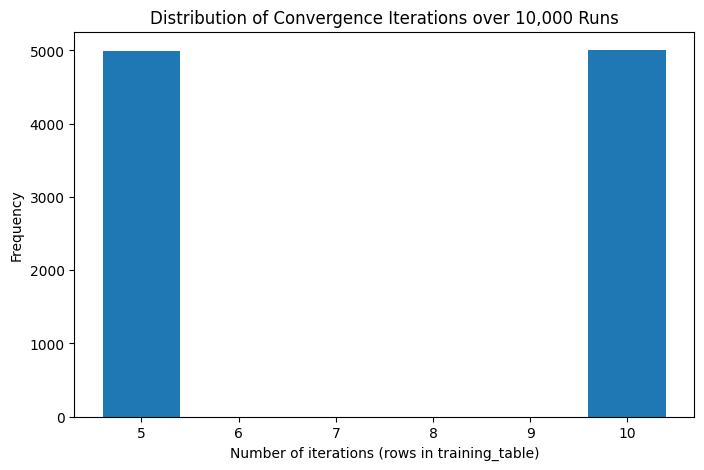

min: 5  max: 10  average: 7.5025


In [69]:
from typing import Counter
# Exercise #6: repeat 10K times and plot the histogram for the total number of iterations

# data samples and target values
dataset = [[1,3],[2,1],[3,4],[4,2]]
targets = [1.0,-1.0,1.0,-1.0]

# initial set of weights
weights = [-3.0,0.0,2.0]

# forces for a random sequnece of samples
sampleseq = []

# add your code here...
counts = []
for i in range(10000):
    training_table = pla_train(dataset,targets,weights,sampleseq)
    counts.append(training_table.shape[0])

plt.figure(figsize=(8,5))
plt.hist(counts, bins=range(min(counts),max(counts)+2), align='left', rwidth=0.8)
plt.xlabel('Number of iterations (rows in training_table)')
plt.ylabel('Frequency')
plt.title('Distribution of Convergence Iterations over 10,000 Runs')
plt.show()

print('min:', min(counts), ' max:', max(counts), ' average:', sum(counts)/len(counts))


In [70]:
# What are your conclusions from exercise #6?
# <with 10,000 runs, convergence time is clearly bimodal: every run take exactly 5 or 10 iterations, roughly 50/50 (average 7.489). This confirms that for the small dataset, the random sampling order produces only two convergence paths>

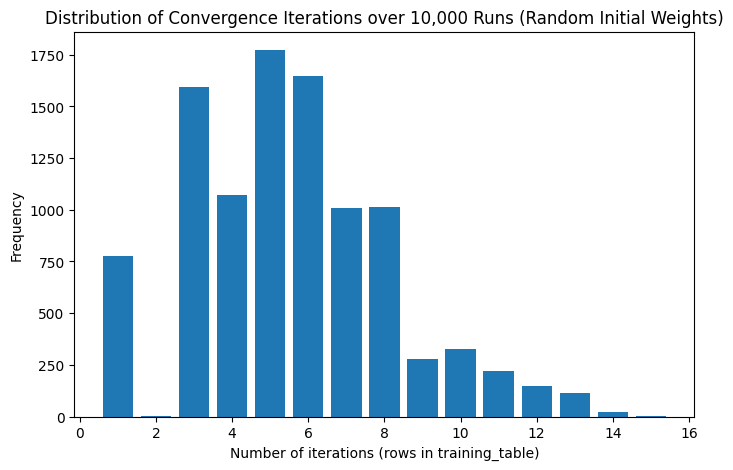

min: 1  max: 15  average: 5.5564


In [71]:
# Exercise #7: repeat again 10K times and plot the histogram but use random initial weights

# data samples and target values
dataset = [[1,3],[2,1],[3,4],[4,2]]
targets = [1.0,-1.0,1.0,-1.0]

# forces for a random initial set of weights
weights = []

# forces for a random sequnece of samples
sampleseq = []

# add your code here...
counts = []
for i in range(10000):
    training_table = pla_train(dataset,targets,weights,sampleseq)
    counts.append(training_table.shape[0])

plt.figure(figsize=(8,5))
plt.hist(counts, bins=range(min(counts),max(counts)+2), align='left', rwidth=0.8)
plt.xlabel('Number of iterations (rows in training_table)')
plt.ylabel('Frequency')
plt.title('Distribution of Convergence Iterations over 10,000 Runs (Random Initial Weights)')
plt.show()

print('min:', min(counts), ' max:', max(counts), ' average:', sum(counts)/len(counts))


In [72]:
# What are you main observations? How results in exercise #7 differ from those in exercise #6?
# <#6 produced bimodal distribution, #7 produce a much wider, smoother, right skewed distributions. Hence key difference is shape. The average also dropped showing random starts converge faster. so the convergence speed depends on initial weights and the sampling order. >

In [73]:
# Exercise #8: use the PLA_TRAIN funtion in Part 1 to create the new funtion PlA_TRAIN_LR,
# which incorporates a new input parameter: lrate (learning rate).

# Notice you only need to modify one line of code to incorporate the learning rate into the
# perceptron learning algorithm, i.e. new = wt[-1] - lrate*error*xt

def pla_train_lr(dtx,tgt,wgt,seq,nsteps=1000,thld=0.001,lrate=1.0):

# add your code here...

# initialization step
    data = [np.array(xn) for xn in [[1]+xy for xy in dtx]]
    target = tgt.copy()
    if len(wgt)==3: wt = [np.array(wgt)]
    else: wt = [np.array([rd.uniform(-3.0,3.0) for x in range(3)])]
    if len(seq)>0: nvals = seq.copy()
    else: nvals = [rd.randint(0,len(data)-1) for x in range(nsteps)]
    mse = [pla_mse(data,target,wt[-1])]

    # perceptron learning algorithm
    for k,n in enumerate(nvals):
        if mse[-1]<thld: break
        xt = data[n]
        yt = np.sign(sum(xt*wt[-1]))
        error = yt - target[n]
        if error == 0.0: continue
        new = wt[-1] - lrate*error*xt
        wt.append(new)
        mse.append(pla_mse(data,target,wt[-1]))
        if mse[-1]<thld: break

    # stores the training history into a data frame
    platrn = pd.DataFrame(np.array(wt),columns=['W0','W1','W2'])
    platrn['slope'] = -platrn['W1'].values/platrn['W2'].values
    platrn['intercept'] = -platrn['W0'].values/platrn['W2'].values
    platrn['mse'] = mse
    return platrn



learning rate = 0.0625  -> average iterations = 12.0566
learning rate = 0.25  -> average iterations = 6.3818
learning rate = 0.5  -> average iterations = 5.756
learning rate = 1.0  -> average iterations = 5.59
learning rate = 2.0  -> average iterations = 5.4864
learning rate = 4.0  -> average iterations = 5.4732
learning rate = 8.0  -> average iterations = 5.4182


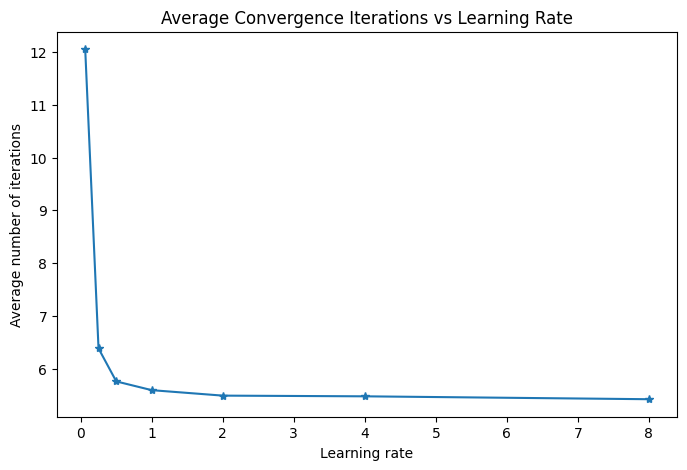

In [74]:
# Exercise #9: use your newly created function PLA_TRAIN_LR to study the effect of the
# learning rate in the perceptron learning algorithm behavior

# For each of the learning rate values provided below, run 10K times the training function
# and compute the average number of iterations needed for the algorithm to finish. Display
# the resulting values and generate a plot of average iteration steps vs learning rates.

# data samples and target values
dataset = [[1,3],[2,1],[3,4],[4,2]]
targets = [1.0,-1.0,1.0,-1.0]

# uses random initial weights and sample sequences
weights = []
sampleseq = []

# use the following values for the learning rate parameter
learning_rates = [0.0625,0.25,0.5,1.0,2.0,4.0,8.0]

# add your code here...
avg_iters = []
for lr in learning_rates:
    counts = []
    for i in range(10000):
        training_table = pla_train_lr(dataset,targets,weights,sampleseq,lrate=lr)
        counts.append(training_table.shape[0])
    avg_iters.append(sum(counts)/len(counts))
    print('learning rate =', lr, ' -> average iterations =', sum(counts)/len(counts))

plt.figure(figsize=(8,5))
plt.plot(learning_rates, avg_iters, '*-')
plt.xlabel('Learning rate')
plt.ylabel('Average number of iterations')
plt.title('Average Convergence Iterations vs Learning Rate')
plt.show()


In [75]:
# What are you main observations from exercise #9?
# <1. average convergence iterations drops as the LR increses, then flatten out at large LR. 2. This happens because small LR means each correction barely moves the weights so more updates are needed to rotate the boundary into a separating position. 3. Unlike the GD, there is no sign of algorithm becoming unstable or oscillating at high LR. >

learning rate = 0.0625  -> average iterations = 12.7224
learning rate = 0.25  -> average iterations = 7.0509
learning rate = 0.5  -> average iterations = 6.3341
learning rate = 1.0  -> average iterations = 6.0824
learning rate = 2.0  -> average iterations = 5.916
learning rate = 4.0  -> average iterations = 6.0742
learning rate = 8.0  -> average iterations = 6.1447


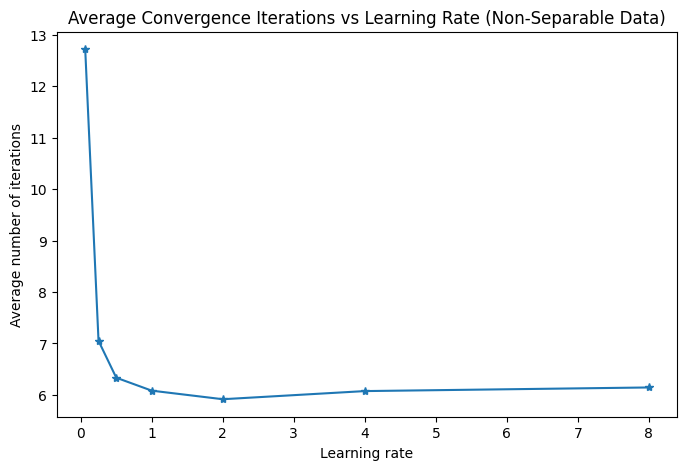

In [76]:
# Exercise #10: repeat the previous exercise but consider this time the new provided dataset,
# which includes an additional data point that makes the classification problem unsolvable
# by means of a single separation boundary line

# Notice that you need to increase the threshold value for the preceptron learning algorithm
# to stop when only one data sample is misclassified (consider thld=0.9).

# data samples and target values
dataset = [[1,3],[2,1],[3,4],[4,2],[2,3.5]]
targets = [1.0,-1.0,1.0,-1.0,-1.0]

# uses random initial weights and sample sequences
weights = []
sampleseq = []

# use the following values for the learning rate parameter
learning_rates = [0.0625,0.25,0.5,1.0,2.0,4.0,8.0]

# add your code here...
avg_iters = []
for lr in learning_rates:
    counts = []
    for i in range(10000):
        training_table = pla_train_lr(dataset,targets,weights,sampleseq,thld=0.9,lrate=lr)
        counts.append(training_table.shape[0])
    avg_iters.append(sum(counts)/len(counts))
    print('learning rate =', lr, ' -> average iterations =', sum(counts)/len(counts))

plt.figure(figsize=(8,5))
plt.plot(learning_rates, avg_iters, '*-')
plt.xlabel('Learning rate')
plt.ylabel('Average number of iterations')
plt.title('Average Convergence Iterations vs Learning Rate (Non-Separable Data)')
plt.show()



In [77]:
# What are you main observations from exercise #10? Are these consistent with your previous
# observations from exercise #9?
# <1. Partly consitent,Like #9 very small LR are costly in both cases. 2. avg iterations double compared to LR =0.5 3. The curves diverge at higher rates, #9 improving but in this case the curve hits minimum and rises again afterward a U- shape. 3. This happens because data is not perfect seprator. 4. The best LR depends upon data, for separable data, bigger is better upto the point, for non- separatble data, there is a real sweet spot beyond which larger rates starts becoming costly.  >


## Part 3: Term Project Ideas...

In [78]:
# Write two ideas you want to consider for your Term project and indicate who your teammate will be
# For each, provide: a title, a brief description, and some bullet points about why you want to consider it

In [79]:
#
"""
Title: CareLoop: A Post Discharge Recovery Check-In Agent
Description: A voice agent that calls patients after they leave the hospital to see how recovery is going. It knows the patient's discharge instructions and medication schedule, asks how they're feeling, listens for concerning symptoms, confirms they're taking medications correctly, and answers basic questions about their care plan. Critically, it is not a diagnostic tool it surfaces red flags and routes anything serious to a human nurse or, for emergencies, to existing emergency services. The aim is a warm, patient check-in that feels like a real care team member following up.
Why it's worth considering:

Exercises the full voice pipeline on a real, high value use case. STT transcribes what the patient reports, an agentic workflow decides what to ask next based on their discharge plan, and ElevenLabs TTS delivers a calm, consistent voice so you build and tune each stage end to end.
End of turn detection genuinely matters here. Post surgical and elderly patients often speak slowly, pause to find words, or get short of breath. Naive VAD will cut them off mid-sentence, which makes this an ideal testbed for the turn detection strategies in the course and getting it wrong has real human cost.
Forces strong conversational state and presence. The agent must remember the patient's specific medications, their answers from earlier in the call (and ideally prior calls), and their care plan, so it can ask informed follow-ups ("Yesterday you mentioned the incision felt warm — is that better or worse today?"). This is the course's "state and presence" idea applied where it really counts.
Latency is tied directly to trust. A laggy, robotic feeling agent erodes patient confidence in a moment where reassurance matters; this gives you a concrete, human reason to measure and minimize latency across the pipeline.
Maps cleanly onto LiveKit's production story. A hospital system following up with thousands of discharged patients across a region is a natural fit for the cloud + real time networking infrastructure the course emphasizes.
Safety and escalation become first class design work. Building red flag detection (chest pain, difficulty breathing, signs of infection) that reliably hands off to clinicians or emergency services is a meaningful
"""

In [80]:
#
"""
Title: Entropy-Adaptive Patching for Diffusion Transformers ("Mini-D²iT")

Brief description: A standard Diffusion Transformer cuts an image into equal-sized patches and spends the same number of tokens on every region, a detailed eye and a flat patch of sky get treated identically. This project measures how busy each region is using entropy, then gives busy regions more tokens and smooth regions fewer (via a fixed token budget), and tests whether that beats a uniform DiT at the same compute budget. It's a from-scratch, isolated reimplementation of the core idea behind D²iT (CVPR 2025), without its heavier dual-VAE machinery.

Why I want to consider it:
It has a single, clean, testable hypothesis: there should be a sweet spot near a 50/50 fine/coarse token split, with "all fine" and "all coarse" both worse so even a negative result is a valid finding.
It builds directly on the from scratch DiT I'll already have from the course, so I'm extending my own model rather than wrapping an API.
"""

In [81]:
# Jainish Patel